In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm


In [3]:
#Load dataset
merged_data_file_path = r"C:\Users\Antonio\Downloads\feature_matrix.csv"
merged_data = pd.read_csv(merged_data_file_path)

#Drop unnecessary columns
cols_to_drop = [col for col in merged_data.columns if 'locnan' in col]
cols_to_drop += ['date', 'bin', 'ret', 'ecm_spread', 'z_score', 
                 'ecm_spread_lag1', 'ecm_spread_lag2', 
                 'corn_Close', 'soybean_Close','corn_Volume', 
                 'soybean_Volume', 'corn_log_return', 'soybean_log_return']
df_clean = merged_data.drop(columns=cols_to_drop)

#Keep only numeric columns
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df_clean[numeric_cols]

#Handle missing values
#Drop columns with >50% missing values
df_numeric = df_numeric.loc[:, df_numeric.isna().mean() < 0.5]
#Fill remaining missing values with column mean
df_numeric = df_numeric.fillna(df_numeric.mean())


print(f"Number of features after cleaning: {df_numeric.shape[1]}")
print(f"Number of rows after cleaning: {df_numeric.shape[0]}")
print(df_numeric.head())

Number of features after cleaning: 118
Number of rows after cleaning: 5303
   temperature_2m_mean_loc1.0  temperature_2m_mean_loc2.0  \
0                    0.390500                    7.551250   
1                   -0.940750                    7.767918   
2                   -1.942833                    8.486667   
3                    2.811333                   13.780417   
4                    7.442583                   10.847084   

   temperature_2m_mean_loc3.0  precipitation_sum_loc1.0  \
0                    5.203417                 52.799995   
1                    7.572166                 11.000001   
2                   11.097168                  0.000000   
3                   10.599249                  0.000000   
4                    9.172167                 32.500000   

   precipitation_sum_loc2.0  precipitation_sum_loc3.0  \
0                  0.000000                       0.8   
1                  0.000000                       0.0   
2                 30.800001     

In [4]:
#Standardize features 
from sklearn.preprocessing import StandardScaler
df_scaled = StandardScaler().fit_transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

print(f"Number of features after cleaning: {df_scaled.shape[1]}")
print(f"Number of rows after cleaning: {df_scaled.shape[0]}")
print(df_scaled.head())

Number of features after cleaning: 118
Number of rows after cleaning: 5303
   temperature_2m_mean_loc1.0  temperature_2m_mean_loc2.0  \
0                   -1.071539                   -2.058171   
1                   -1.200712                   -2.016141   
2                   -1.297945                   -1.876712   
3                   -0.836642                   -0.849791   
4                   -0.387266                   -1.418821   

   temperature_2m_mean_loc3.0  precipitation_sum_loc1.0  \
0                   -1.086331                  7.749965   
1                   -0.657732                  1.243959   
2                   -0.019921                 -0.468149   
3                   -0.110014                 -0.468149   
4                   -0.368229                  4.590350   

   precipitation_sum_loc2.0  precipitation_sum_loc3.0  \
0                 -0.195211                 -0.293103   
1                 -0.195211                 -0.517827   
2                  6.270096     

In [5]:
#PCA 
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_scaled)
pca_data = pca.transform(df_scaled)

In [6]:

path = r"C:\Users\Antonio\Downloads\SojaSerieHist (1).xls"

raw = pd.read_excel(path, header=None)

# show first 12 rows and first 12 columns
raw.iloc[:12, :12]
soy_data_brazil = pd.read_excel(path, header=5)
# clean columns
soy_data_brazil = soy_data_brazil.dropna(axis=1, how="all")
soy_data_brazil = soy_data_brazil.rename(columns={soy_data_brazil.columns[0]: "regiao_uf"})
soy_data_brazil = soy_data_brazil.replace("-", np.nan)

# now melt
soy_long = soy_data_brazil.melt(
    id_vars="regiao_uf",
    var_name="safra",
    value_name="area_mil_ha"
)

soy_long.head(20)
soy_long["area_mil_ha"] = pd.to_numeric(
    soy_long["area_mil_ha"],
    errors="coerce")

In [7]:

path_corn = r"C:\Users\Antonio\Downloads\MilhoTotalSerieHist (1).xls"

# ---- Inspect raw to confirm header row (optional but good practice) ----
raw_corn = pd.read_excel(path_corn, header=None)
raw_corn.iloc[:12, :12]   # visually confirm header row
corn_data_brazil = pd.read_excel(path_corn, header=5)
# ---- Clean columns ----
corn_data_brazil = corn_data_brazil.dropna(axis=1, how="all")
corn_data_brazil = corn_data_brazil.rename(
    columns={corn_data_brazil.columns[0]: "regiao_uf"}
)

# replace "-" with NaN
corn_data_brazil = corn_data_brazil.replace("-", np.nan)

# ---- Melt to long format ----
corn_long = corn_data_brazil.melt(
    id_vars="regiao_uf",
    var_name="safra",
    value_name="area_mil_ha"
)

corn_long.head(20)


corn_long["area_mil_ha"] = pd.to_numeric(
    corn_long["area_mil_ha"],
    errors="coerce"
)

In [8]:
merged = pd.merge(
    soy_long,
    corn_long,
    on=["regiao_uf", "safra"],
    suffixes=("_soy", "_corn")
)

merged["year"] = merged["safra"].astype(str).str.slice(0, 4).astype(int)

merged["regiao_uf"] = merged["regiao_uf"].astype(str).str.strip()
merged = merged.sort_values(["regiao_uf", "year"])
merged.head(90)

,regiao_uf,safra,area_mil_ha_soy,area_mil_ha_corn,year
3,AC,1976/77,0.0,17.0,1976
40,AC,1977/78,0.0,17.5,1977
77,AC,1978/79,0.0,13.0,1978
114,AC,1979/80,0.0,17.0,1979
151,AC,1980/81,0.0,18.0,1980
...,...,...,...,...,...
1384,AL,2015/16,0.0,28.3,2015
1421,AL,2016/17,0.0,37.2,2016
1458,AL,2017/18,2.2,26.2,2017
1495,AL,2018/19,1.6,33.9,2018


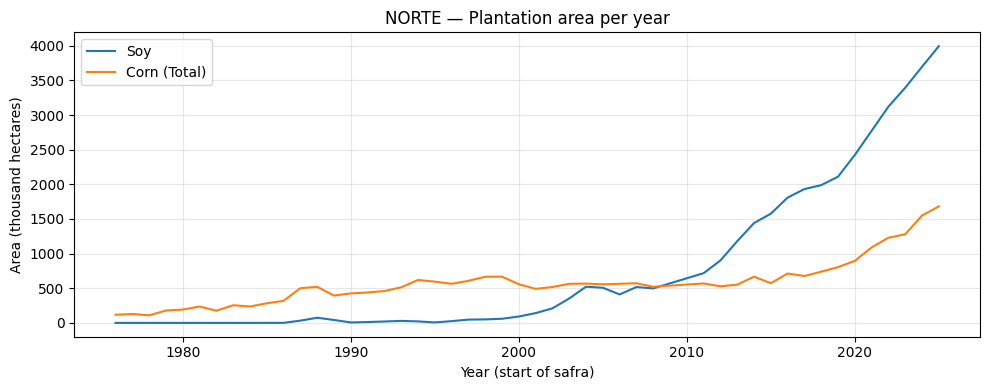

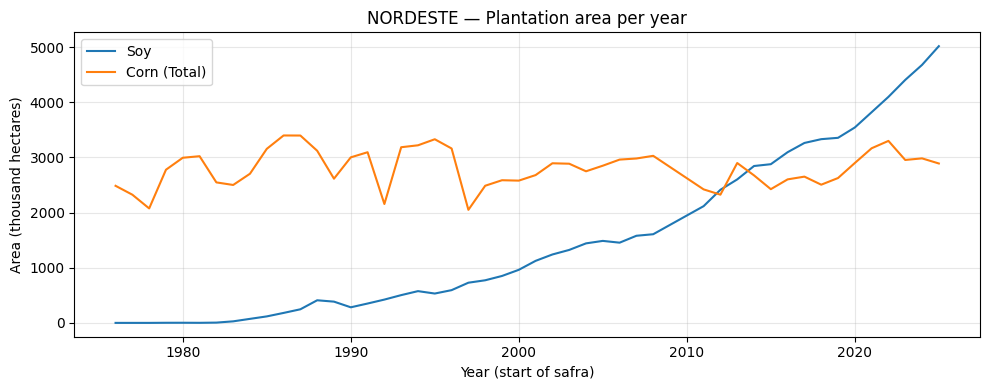

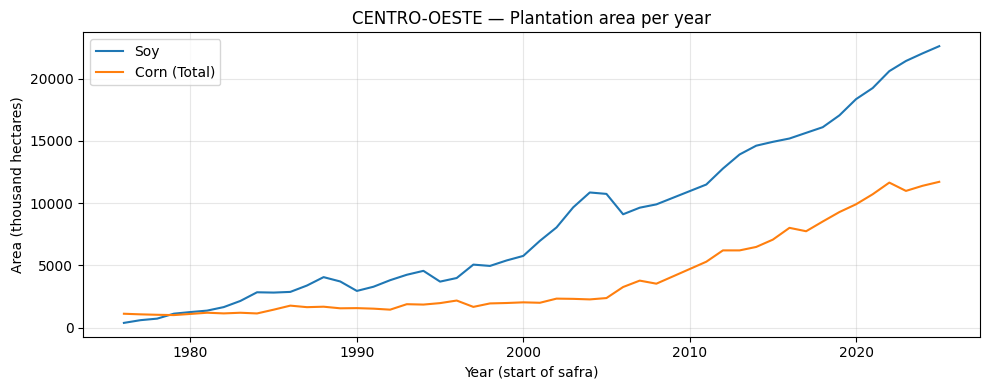

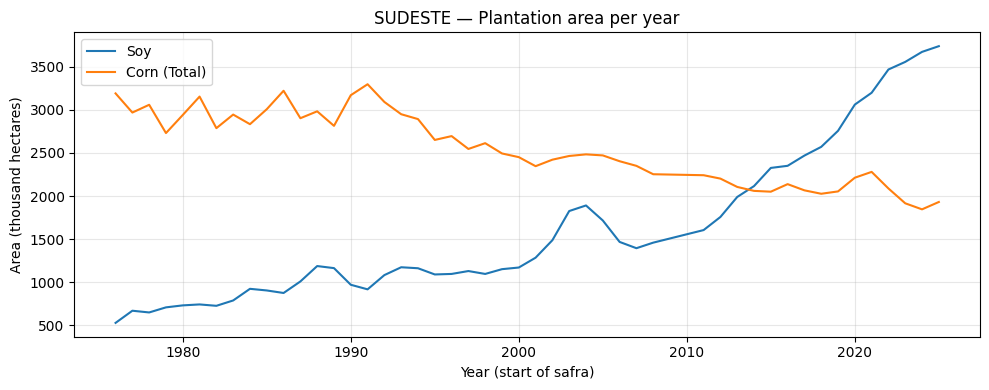

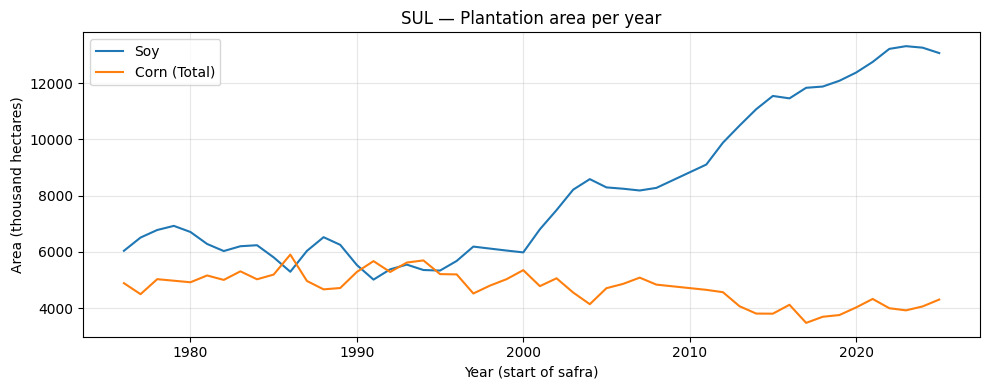

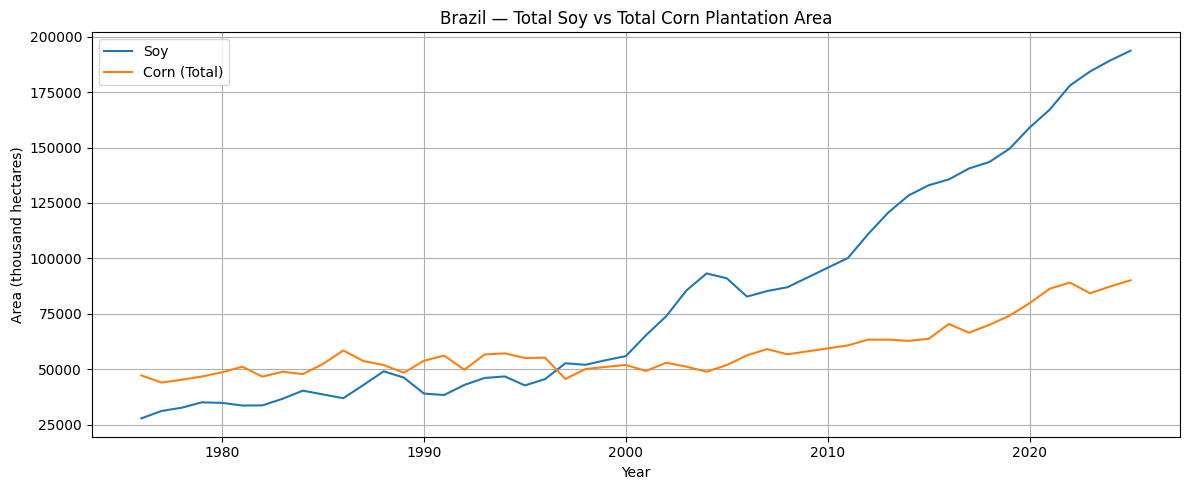

In [32]:
regions = ["NORTE", "NORDESTE", "CENTRO-OESTE", "SUDESTE", "SUL"]

# --- Regional plots ---
for r in regions:
    d = merged_all[merged_all["regiao_uf"] == r].sort_values("year")

    plt.figure(figsize=(10, 4))
    plt.plot(d["year"], d["area_mil_ha_soy"], label="Soy")
    plt.plot(d["year"], d["area_mil_ha_corn"], label="Corn (Total)")
    plt.title(f"{r} — Plantation area per year")
    plt.xlabel("Year (start of safra)")
    plt.ylabel("Area (thousand hectares)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- National total plot ---
national_total = (
    merged_all
    .groupby("year")[["area_mil_ha_soy", "area_mil_ha_corn"]]
    .sum()
    .reset_index()
    .sort_values("year")
)

plt.figure(figsize=(12,5))
plt.plot(national_total["year"], national_total["area_mil_ha_soy"], label="Soy")
plt.plot(national_total["year"], national_total["area_mil_ha_corn"], label="Corn (Total)")
plt.title("Brazil — Total Soy vs Total Corn Plantation Area")
plt.xlabel("Year")
plt.ylabel("Area (thousand hectares)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

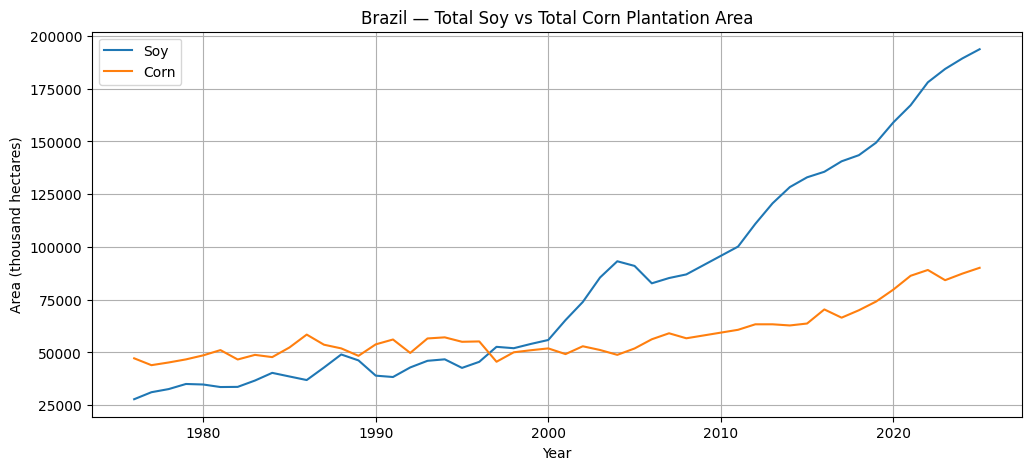

In [54]:
plt.figure(figsize=(12,5))

plt.plot(national["year"], national["area_mil_ha_soy"], label="Soy")
plt.plot(national["year"], national["area_mil_ha_corn"], label="Corn")

plt.title("Brazil — Total Soy vs Total Corn Plantation Area")
plt.xlabel("Year")
plt.ylabel("Area (thousand hectares)")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
national[["area_mil_ha_soy", "area_mil_ha_corn"]].corr()

national["soy_growth"] = national["area_mil_ha_soy"].pct_change()
national["corn_growth"] = national["area_mil_ha_corn"].pct_change()

national[["soy_growth", "corn_growth"]].corr()

,soy_growth,corn_growth
soy_growth,1.000000,-0.421524
corn_growth,-0.421524,1.000000


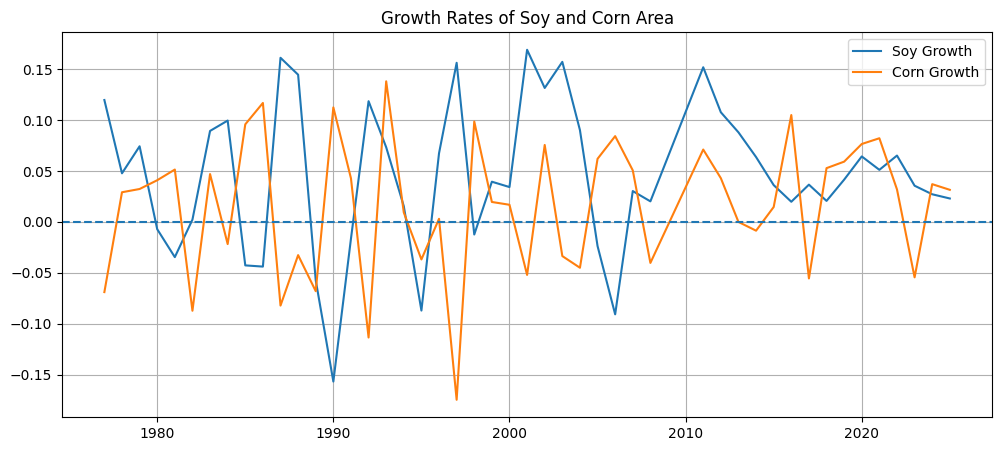

In [56]:

plt.figure(figsize=(12,5))
plt.plot(national["year"], national["soy_growth"], label="Soy Growth")
plt.plot(national["year"], national["corn_growth"], label="Corn Growth")
plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Growth Rates of Soy and Corn Area")
plt.grid(True)
plt.show()

In [57]:
import statsmodels.api as sm

X = sm.add_constant(national["corn_growth"].dropna())
y = national["soy_growth"].dropna()

model = sm.OLS(y, X).fit()
print(model.summary)

<bound method RegressionResults.summary of <statsmodels.regression.linear_model.OLSResults object at 0x000002A3B4E19950>>


In [58]:


path_corn1a = r"C:\Users\Antonio\Downloads\Milho1aSerieHist.xls"

# ---- Inspect raw (optional) ----
raw_corn1a = pd.read_excel(path_corn1a, header=None)
raw_corn1a.iloc[:12, :12]

# ---- Load with correct header ----
corn_data_brazil1a = pd.read_excel(path_corn1a, header=5)

# ---- Clean columns ----
corn_data_brazil1a = corn_data_brazil1a.dropna(axis=1, how="all")
corn_data_brazil1a = corn_data_brazil1a.rename(columns={corn_data_brazil1a.columns[0]: "regiao_uf"})

# replace "-" with NaN and strip spaces in region labels
corn_data_brazil1a = corn_data_brazil1a.replace("-", np.nan)
corn_data_brazil1a["regiao_uf"] = corn_data_brazil1a["regiao_uf"].astype(str).str.strip()

# ---- Melt to long format ----
corn_long1a = corn_data_brazil1a.melt(
    id_vars="regiao_uf",
    var_name="safra",
    value_name="area_mil_ha"
)

# ---- STRONG CLEANING before numeric conversion (fixes your NaNs like AC 1977/78) ----
corn_long1a["area_mil_ha"] = (
    corn_long1a["area_mil_ha"]
    .astype(str)
    .str.replace("\xa0", "", regex=False)   # remove non-breaking spaces
    .str.replace(" ", "", regex=False)      # remove regular spaces
    .str.replace(",", ".", regex=False)     # convert decimal comma to dot if present
    .replace({"nan": np.nan, "None": np.nan, "": np.nan})  # restore true missing
)

corn_long1a["area_mil_ha"] = pd.to_numeric(corn_long1a["area_mil_ha"], errors="coerce")

# also strip safra just in case
corn_long1a["safra"] = corn_long1a["safra"].astype(str).str.strip()

corn_long1a.head(20)

# ---- Prepare for merge ----
corn1a_for_merge = corn_long1a.rename(columns={"area_mil_ha": "area_mil_ha_corn1a"}).copy()
corn1a_for_merge["regiao_uf"] = corn1a_for_merge["regiao_uf"].astype(str).str.strip()
corn1a_for_merge["safra"] = corn1a_for_merge["safra"].astype(str).str.strip()

merged["regiao_uf"] = merged["regiao_uf"].astype(str).str.strip()
merged["safra"] = merged["safra"].astype(str).str.strip()

# ---- Merge ----
merged_all = pd.merge(
    merged,
    corn1a_for_merge[["regiao_uf", "safra", "area_mil_ha_corn1a"]],
    on=["regiao_uf", "safra"],
    how="left"
)

merged_all.head()

,regiao_uf,safra,area_mil_ha_soy,area_mil_ha_corn,year,area_mil_ha_corn1a
0,AC,1976/77,0.0,17.0,1976,17.0
1,AC,1977/78,0.0,17.5,1977,17.5
2,AC,1978/79,0.0,13.0,1978,13.0
3,AC,1979/80,0.0,17.0,1979,17.0
4,AC,1980/81,0.0,18.0,1980,18.0


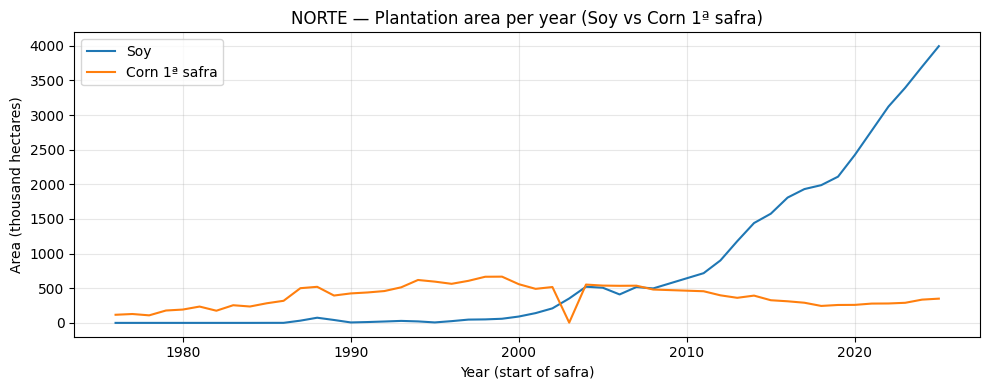

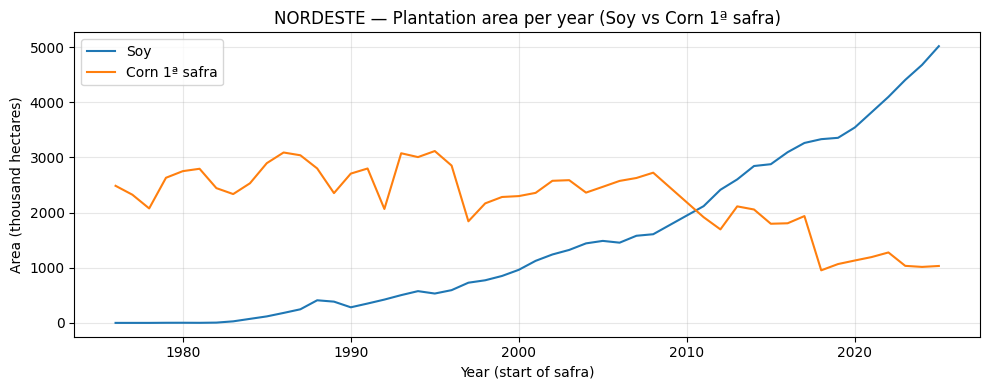

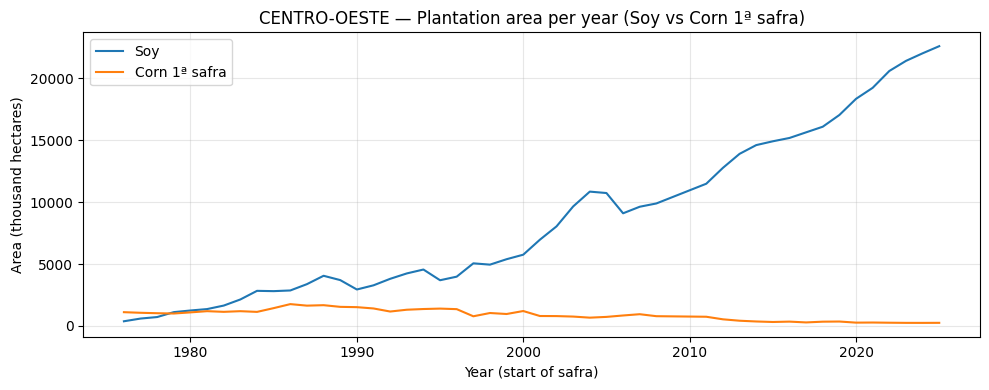

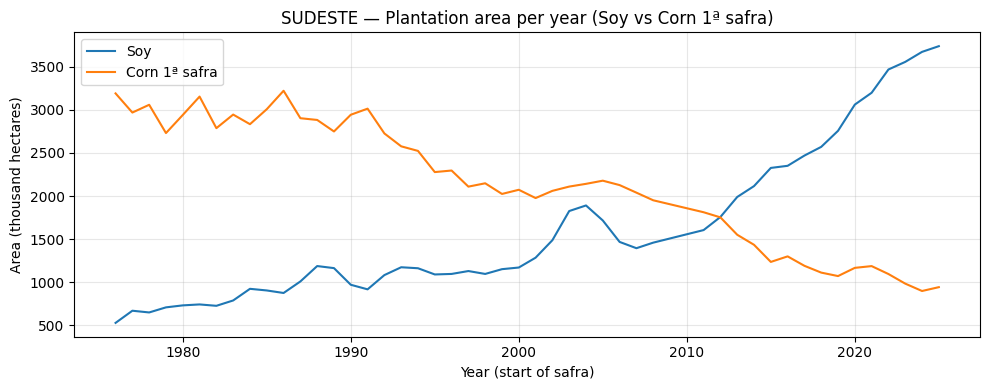

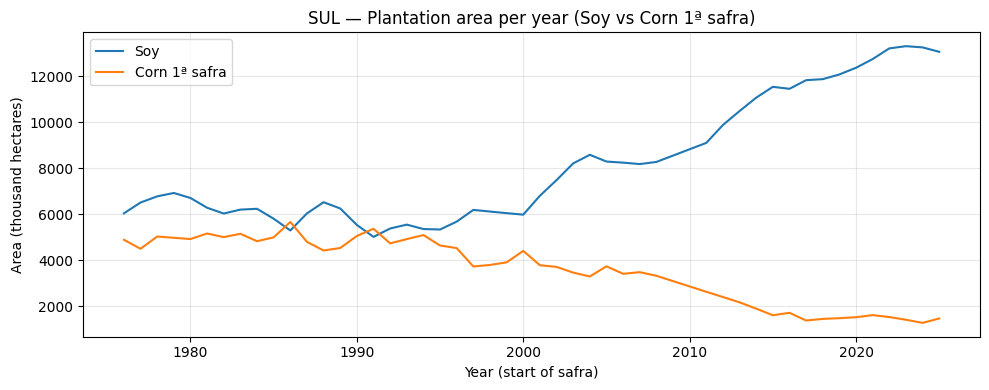

In [59]:
import matplotlib.pyplot as plt

regions = ["NORTE", "NORDESTE", "CENTRO-OESTE", "SUDESTE", "SUL"]

for r in regions:
    d = merged_all[merged_all["regiao_uf"] == r].sort_values("year")

    plt.figure(figsize=(10, 4))
    plt.plot(d["year"], d["area_mil_ha_soy"], label="Soy")
    plt.plot(d["year"], d["area_mil_ha_corn1a"], label="Corn 1ª safra")
    plt.title(f"{r} — Plantation area per year (Soy vs Corn 1ª safra)")
    plt.xlabel("Year (start of safra)")
    plt.ylabel("Area (thousand hectares)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

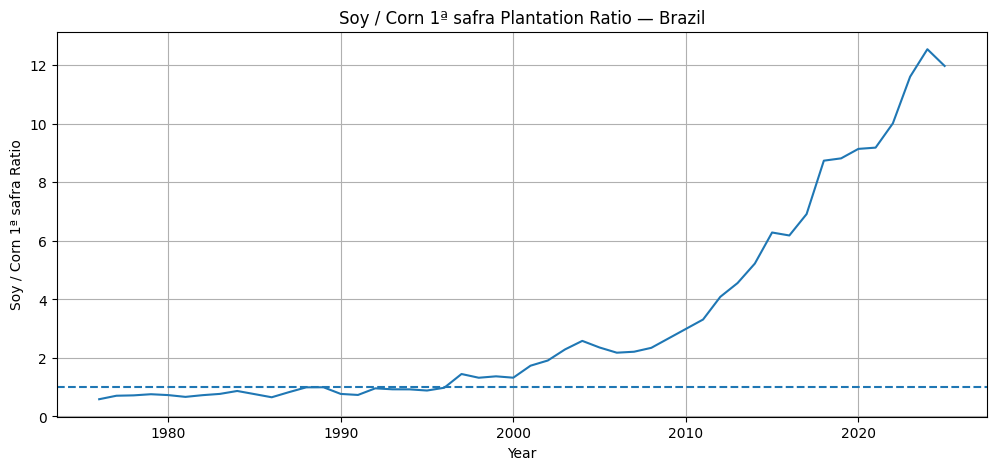

In [60]:
national1a = (
    merged_all.groupby("year")[["area_mil_ha_soy", "area_mil_ha_corn1a"]]
    .sum()
    .reset_index()
    .sort_values("year")
)

national1a["soy_corn1a_ratio"] = national1a["area_mil_ha_soy"] / national1a["area_mil_ha_corn1a"]

plt.figure(figsize=(12, 5))
plt.plot(national1a["year"], national1a["soy_corn1a_ratio"])
plt.axhline(1, linestyle="--")
plt.title("Soy / Corn 1ª safra Plantation Ratio — Brazil")
plt.xlabel("Year")
plt.ylabel("Soy / Corn 1ª safra Ratio")
plt.grid(True)
plt.show()

In [61]:
national1a[["area_mil_ha_soy", "area_mil_ha_corn1a"]].corr()

,area_mil_ha_soy,area_mil_ha_corn1a
area_mil_ha_soy,1.000000,-0.959918
area_mil_ha_corn1a,-0.959918,1.000000


In [62]:
national1a["soy_growth"] = national1a["area_mil_ha_soy"].pct_change()
national1a["corn1a_growth"] = national1a["area_mil_ha_corn1a"].pct_change()

national1a[["soy_growth", "corn1a_growth"]].corr()

,soy_growth,corn1a_growth
soy_growth,1.000000,-0.477607
corn1a_growth,-0.477607,1.000000


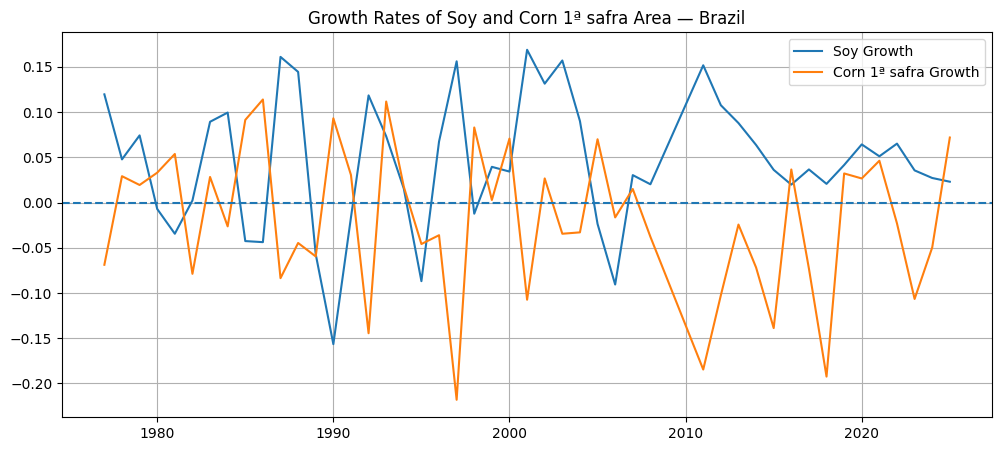

In [63]:
plt.figure(figsize=(12, 5))
plt.plot(national1a["year"], national1a["soy_growth"], label="Soy Growth")
plt.plot(national1a["year"], national1a["corn1a_growth"], label="Corn 1ª safra Growth")
plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Growth Rates of Soy and Corn 1ª safra Area — Brazil")
plt.grid(True)
plt.show()

In [64]:
import os
print(os.getcwd())


soy_prices = pd.read_csv("../data/daily_soybean_prices.csv")
soy_prices.head()

corn_prices = pd.read_csv("../data/daily_corn_prices.csv")
corn_prices.head()


# --- 1) Standardize column names ---
soy_prices.columns = soy_prices.columns.str.lower().str.strip()
corn_prices.columns = corn_prices.columns.str.lower().str.strip()

# --- 2) Identify date and price columns (works for common Yahoo CSV formats) ---
# Date column could be 'date' (most common)
if "date" not in soy_prices.columns or "date" not in corn_prices.columns:
    raise ValueError(f"Couldn't find 'date' column. Soy cols: {soy_prices.columns}, Corn cols: {corn_prices.columns}")

# Choose price column: prefer 'adj close' if present, else 'close'
soy_price_col = "adj close" if "adj close" in soy_prices.columns else "close"
corn_price_col = "adj close" if "adj close" in corn_prices.columns else "close"

# --- 3) Parse dates and keep only needed columns ---
soy = soy_prices[["date", soy_price_col]].copy()
corn = corn_prices[["date", corn_price_col]].copy()

soy["date"] = pd.to_datetime(soy["date"])
corn["date"] = pd.to_datetime(corn["date"])

soy = soy.rename(columns={soy_price_col: "soy_price"})
corn = corn.rename(columns={corn_price_col: "corn_price"})

# --- 4) Merge into one daily price dataframe ---
prices = pd.merge(soy, corn, on="date", how="inner").dropna()

prices.head()



c:\Users\Antonio\Documents\Github\Spring2026-TIC\4_feature_selection


,date,soy_price,corn_price
1,2005-01-03,537.25,201.75
2,2005-01-04,529.75,201.0
3,2005-01-05,534.0,201.5
4,2005-01-06,541.75,208.75
5,2005-01-07,551.75,206.75


In [65]:
import matplotlib.pyplot as plt

national_share_corn = (
    merged_all
    .groupby("year")[["area_mil_ha_corn", "area_mil_ha_corn1a"]]
    .sum()
    .reset_index()
    .sort_values("year")
)

# drop years where total corn is zero (just in case)
national_share_corn = national_share_corn[national_share_corn["area_mil_ha_corn"] > 0]

national_share_corn["share_corn1a"] = (
    national_share_corn["area_mil_ha_corn1a"] /
    national_share_corn["area_mil_ha_corn"]
)

national_share_corn.head()

,year,area_mil_ha_corn,area_mil_ha_corn1a,share_corn1a
0,1976,47189.344,47189.344,1.000000
1,1977,43940.240,43940.240,1.000000
2,1978,45219.252,45219.252,1.000000
3,1979,46679.532,46095.532,0.987489
4,1980,48588.576,47616.576,0.979995


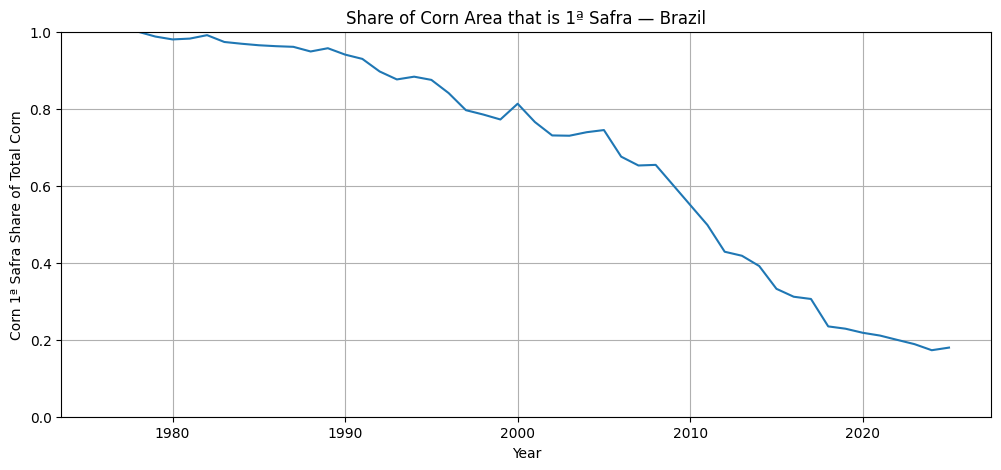

In [66]:
plt.figure(figsize=(12,5))
plt.plot(national_share["year"], national_share["share_corn1a"])
plt.title("Share of Corn Area that is 1ª Safra — Brazil")
plt.xlabel("Year")
plt.ylabel("Corn 1ª Safra Share of Total Corn")
plt.ylim(0,1)
plt.grid(True)
plt.show()